In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
# Load the dataset
df = pd.read_csv("/content/used_cars_data.csv")

In [ ]:
df.head()

,S.No.,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Price
0,0,Maruti Wagon R LXI CNG,Mumbai,2010,72000,CNG,Manual,First,26.60,998,58.16,5.0,1.75
1,1,Hyundai Creta 1.6 CRDi SX Option,Pune,2015,41000,Diesel,Manual,First,19.67,1582,126.20,5.0,12.50
2,2,Honda Jazz V,Chennai,2011,46000,Petrol,Manual,First,18.20,1199,88.70,5.0,4.50
3,3,Maruti Ertiga VDI,Chennai,2012,87000,Diesel,Manual,First,20.77,1248,88.76,7.0,6.00
4,4,Audi A4 New 2.0 TDI Multitronic,Coimbatore,2013,40670,Diesel,Automatic,Second,15.20,1968,140.80,5.0,17.74


In [ ]:
# --- 1. EDA ---
print("--- Initial Info ---")
print(df.info())
print("\n--- Summary Statistics ---")
print(df.describe())
# Check for missing values
missing = df.isnull().sum()
print("\n--- Missing Values ---")
print(missing[missing > 0])



--- Initial Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7253 entries, 0 to 7252
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   S.No.              7253 non-null   int64  
 1   Name               7253 non-null   object 
 2   Location           7253 non-null   object 
 3   Year               7253 non-null   int64  
 4   Kilometers_Driven  7253 non-null   int64  
 5   Fuel_Type          7253 non-null   object 
 6   Transmission       7253 non-null   object 
 7   Owner_Type         7253 non-null   object 
 8   Mileage            7251 non-null   object 
 9   Engine             7207 non-null   object 
 10  Power              7207 non-null   object 
 11  Seats              7200 non-null   float64
 12  Price              6019 non-null   float64
dtypes: float64(2), int64(3), object(8)
memory usage: 736.8+ KB
None

--- Summary Statistics ---
             S.No.         Year  Kilometers_Driven     

In [ ]:
# Clean 'Mileage' column
df['Mileage'] = df['Mileage'].str.replace(' km/kg', '').str.replace(' kmpl', '').astype(float)

# Clean 'Power' column
df['Power'] = df['Power'].str.replace(' bhp', '').replace('null', np.nan).astype(float)

print("--- Data types after conversion ---")
print(df[['Mileage', 'Power']].info())
print("\n--- First 5 rows of cleaned Mileage and Power ---")
display(df[['Mileage', 'Power']].head())

--- Data types after conversion ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7253 entries, 0 to 7252
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Mileage  7251 non-null   float64
 1   Power    7078 non-null   float64
dtypes: float64(2)
memory usage: 113.5 KB
None

--- First 5 rows of cleaned Mileage and Power ---


,Mileage,Power
0,26.60,58.16
1,19.67,126.20
2,18.20,88.70
3,20.77,88.76
4,15.20,140.80


In [ ]:
# Clean 'Engine' column by removing ' CC' and converting to nullable integer type
df['Engine'] = df['Engine'].str.replace(' CC', '', regex=False)
df['Engine'] = pd.to_numeric(df['Engine'], errors='coerce').astype(pd.Int64Dtype())

print("--- Data types after conversion ---")
print(df['Engine'].info())
print("\n--- First 5 rows of cleaned Engine ---")
display(df['Engine'].head())

--- Data types after conversion ---
<class 'pandas.core.series.Series'>
RangeIndex: 7253 entries, 0 to 7252
Series name: Engine
Non-Null Count  Dtype
--------------  -----
7207 non-null   Int64
dtypes: Int64(1)
memory usage: 63.9 KB
None

--- First 5 rows of cleaned Engine ---


,Engine
0,998
1,1582
2,1199
3,1248
4,1968


In [ ]:
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
categorical_cols = df.select_dtypes(include='object').columns.tolist()

print("Numerical columns:", numerical_cols)
print("Categorical columns:", categorical_cols)

Numerical columns: ['S.No.', 'Year', 'Kilometers_Driven', 'Mileage', 'Engine', 'Power', 'Seats', 'Price']
Categorical columns: ['Name', 'Location', 'Fuel_Type', 'Transmission', 'Owner_Type']


In [ ]:
# Impute missing values with the median for numerical columns
for col in ['Mileage', 'Engine', 'Power', 'Seats', 'Price']:
    if df[col].isnull().any():
        median_val = df[col].median()
        df[col] = df[col].fillna(median_val)
        print(f"Missing values in '{col}' filled with median: {median_val}")

print("\n--- Missing values after imputation ---")
print(df.isnull().sum()[df.isnull().sum() > 0])

Missing values in 'Mileage' filled with median: 18.16
Missing values in 'Engine' filled with median: 1493.0
Missing values in 'Power' filled with median: 94.0
Missing values in 'Seats' filled with median: 5.0
Missing values in 'Price' filled with median: 5.64

--- Missing values after imputation ---
Series([], dtype: int64)


### Outlier Detection using Box Plots

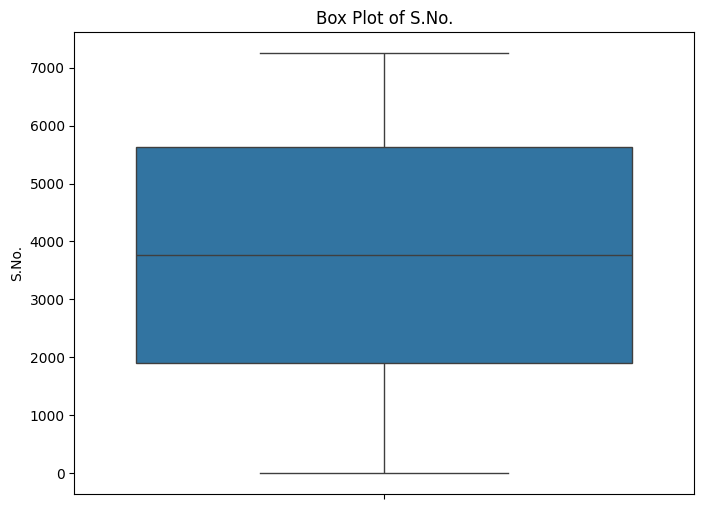

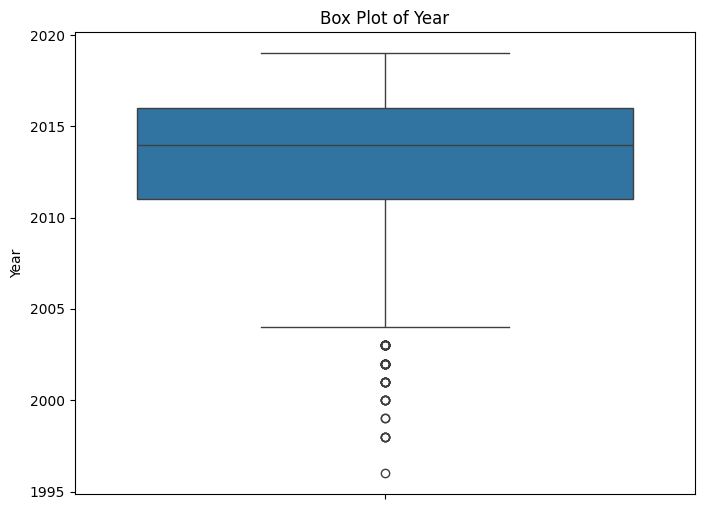

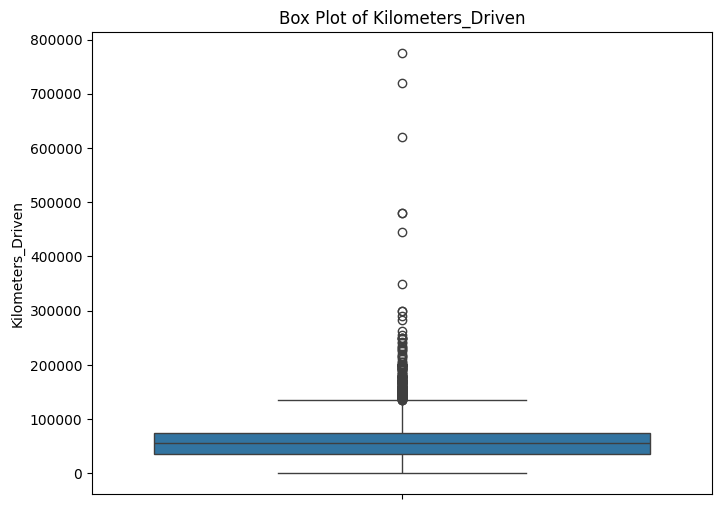

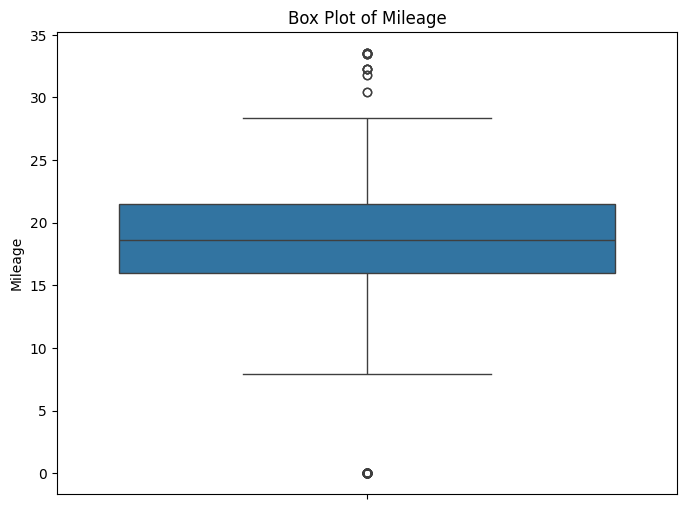

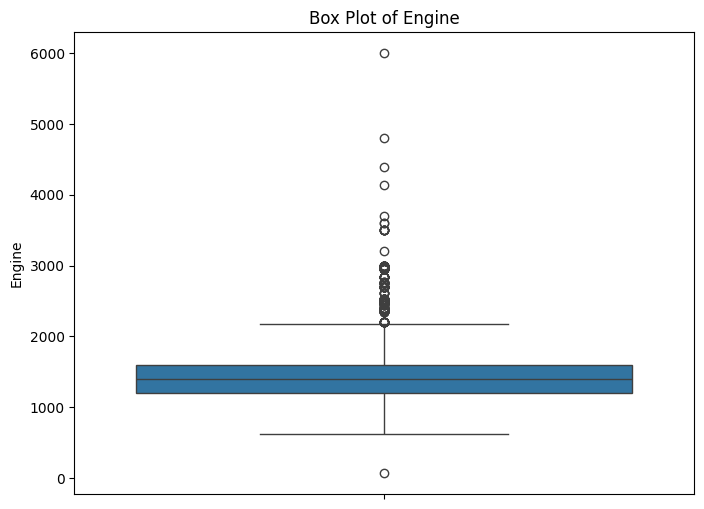

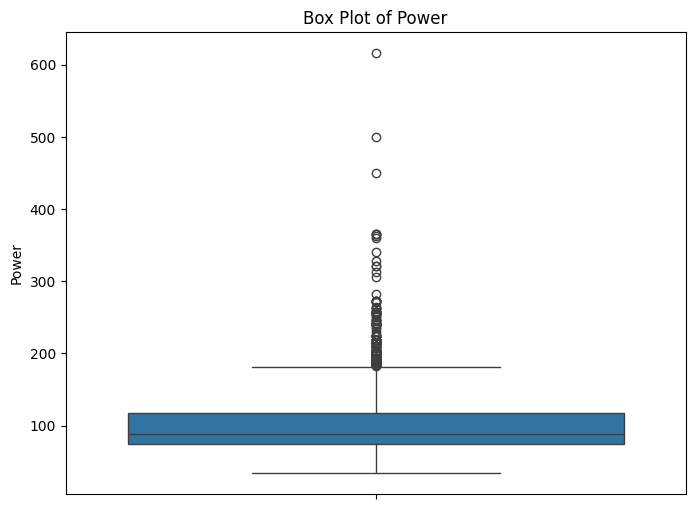

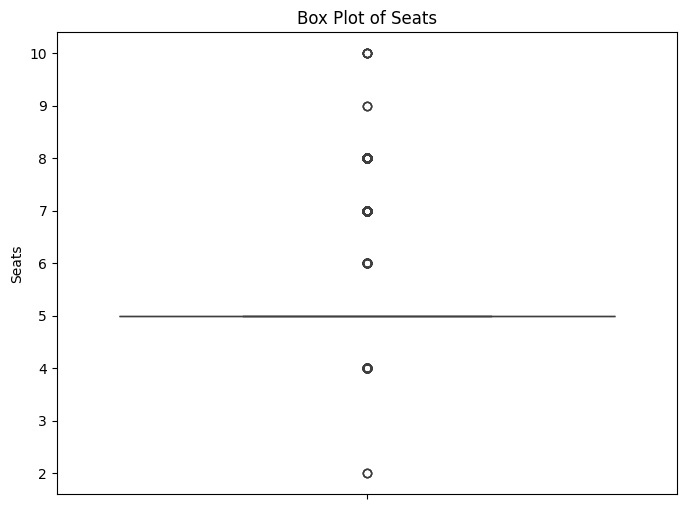

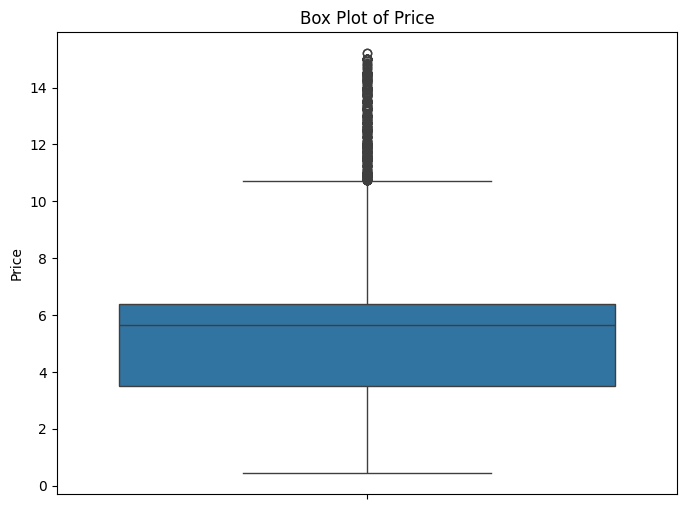

In [ ]:
for col in numerical_cols:
    plt.figure(figsize=(8, 6))
    sns.boxplot(y=df[col])
    plt.title(f'Box Plot of {col}')
    plt.ylabel(col)
    plt.show()

In [ ]:
df = df.drop('S.No.', axis=1)
print(" 'S.No.' column dropped successfully.")
display(df.head())

 'S.No.' column dropped successfully.


,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Price
0,Maruti Wagon R LXI CNG,Mumbai,2010,72000,CNG,Manual,First,26.60,998,58.16,5.0,1.75
1,Hyundai Creta 1.6 CRDi SX Option,Pune,2015,41000,Diesel,Manual,First,19.67,1582,126.20,5.0,12.50
2,Honda Jazz V,Chennai,2011,46000,Petrol,Manual,First,18.20,1199,88.70,5.0,4.50
3,Maruti Ertiga VDI,Chennai,2012,87000,Diesel,Manual,First,20.77,1248,88.76,7.0,6.00
5,Hyundai EON LPG Era Plus Option,Hyderabad,2012,75000,LPG,Manual,First,21.10,814,55.20,5.0,2.35


### Outlier Treatment using IQR Method

Outliers in 'Year' capped. Lower Bound: 2003.50, Upper Bound: 2023.50
Outliers in 'Kilometers_Driven' capped. Lower Bound: -25000.00, Upper Bound: 135000.00
Outliers in 'Mileage' capped. Lower Bound: 7.75, Upper Bound: 29.75
Outliers in 'Engine' capped. Lower Bound: 606.00, Upper Bound: 2182.00
Outliers in 'Power' capped. Lower Bound: 9.05, Upper Bound: 182.25
Outliers in 'Price' capped. Lower Bound: -0.83, Upper Bound: 10.74

--- Box plots after outlier capping ---


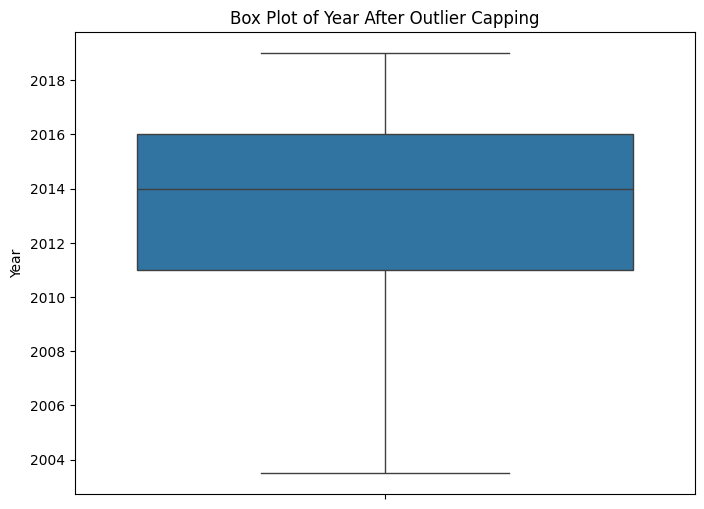

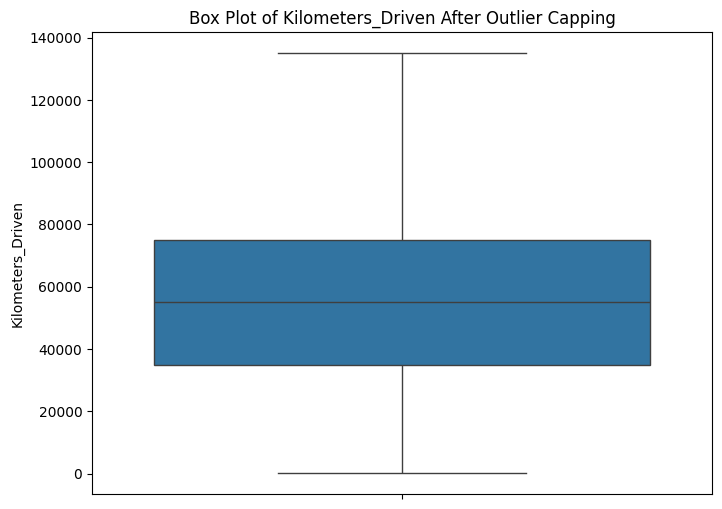

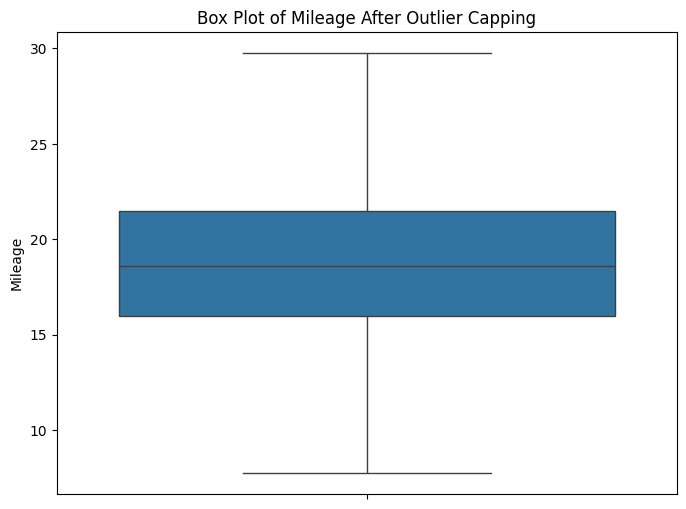

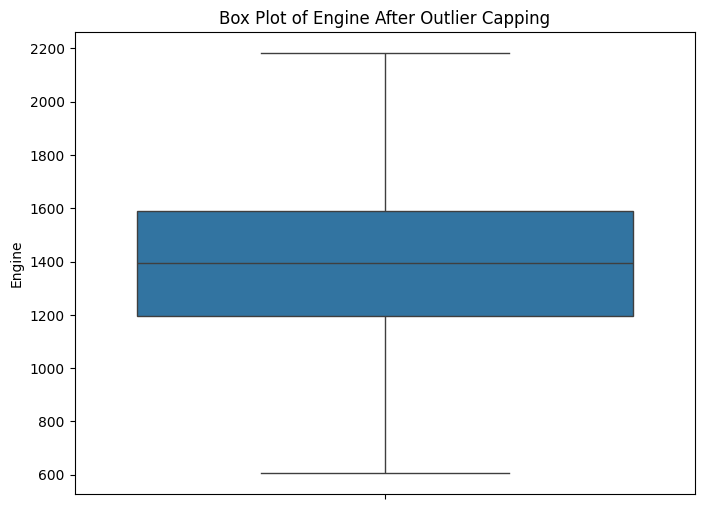

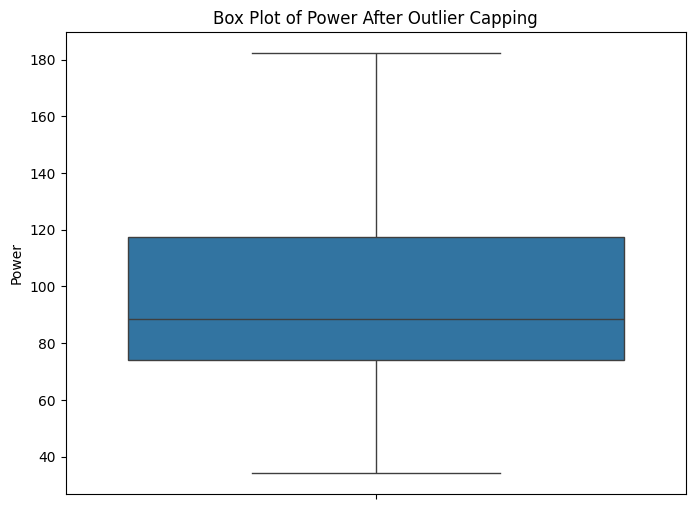

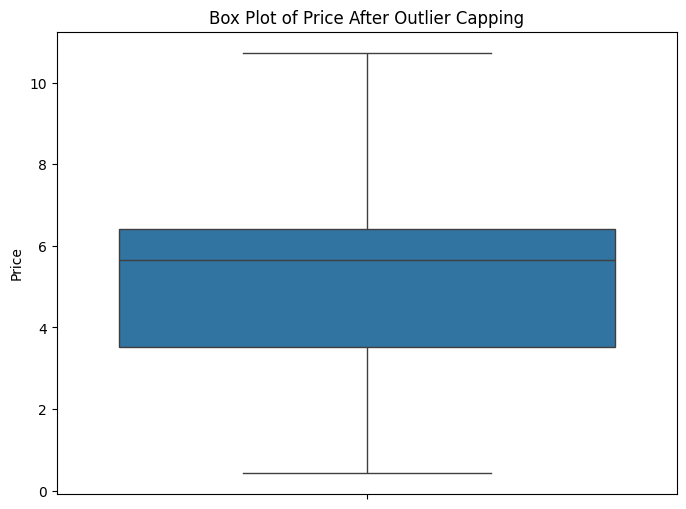

In [ ]:
for col in ['Year', 'Kilometers_Driven', 'Mileage', 'Engine', 'Power', 'Price']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Cap outliers: values below lower_bound become lower_bound, values above upper_bound become upper_bound
    df[col] = np.where(df[col] < lower_bound, lower_bound, df[col])
    df[col] = np.where(df[col] > upper_bound, upper_bound, df[col])

    print(f"Outliers in '{col}' capped. Lower Bound: {lower_bound:.2f}, Upper Bound: {upper_bound:.2f}")

print("\n--- Box plots after outlier capping ---")
for col in ['Year', 'Kilometers_Driven', 'Mileage', 'Engine', 'Power', 'Price']:
    plt.figure(figsize=(8, 6))
    sns.boxplot(y=df[col])
    plt.title(f'Box Plot of {col} After Outlier Capping')
    plt.ylabel(col)
    plt.show()

### Univariate Analysis

#### Distribution of Numerical Features (Histograms and KDE plots)

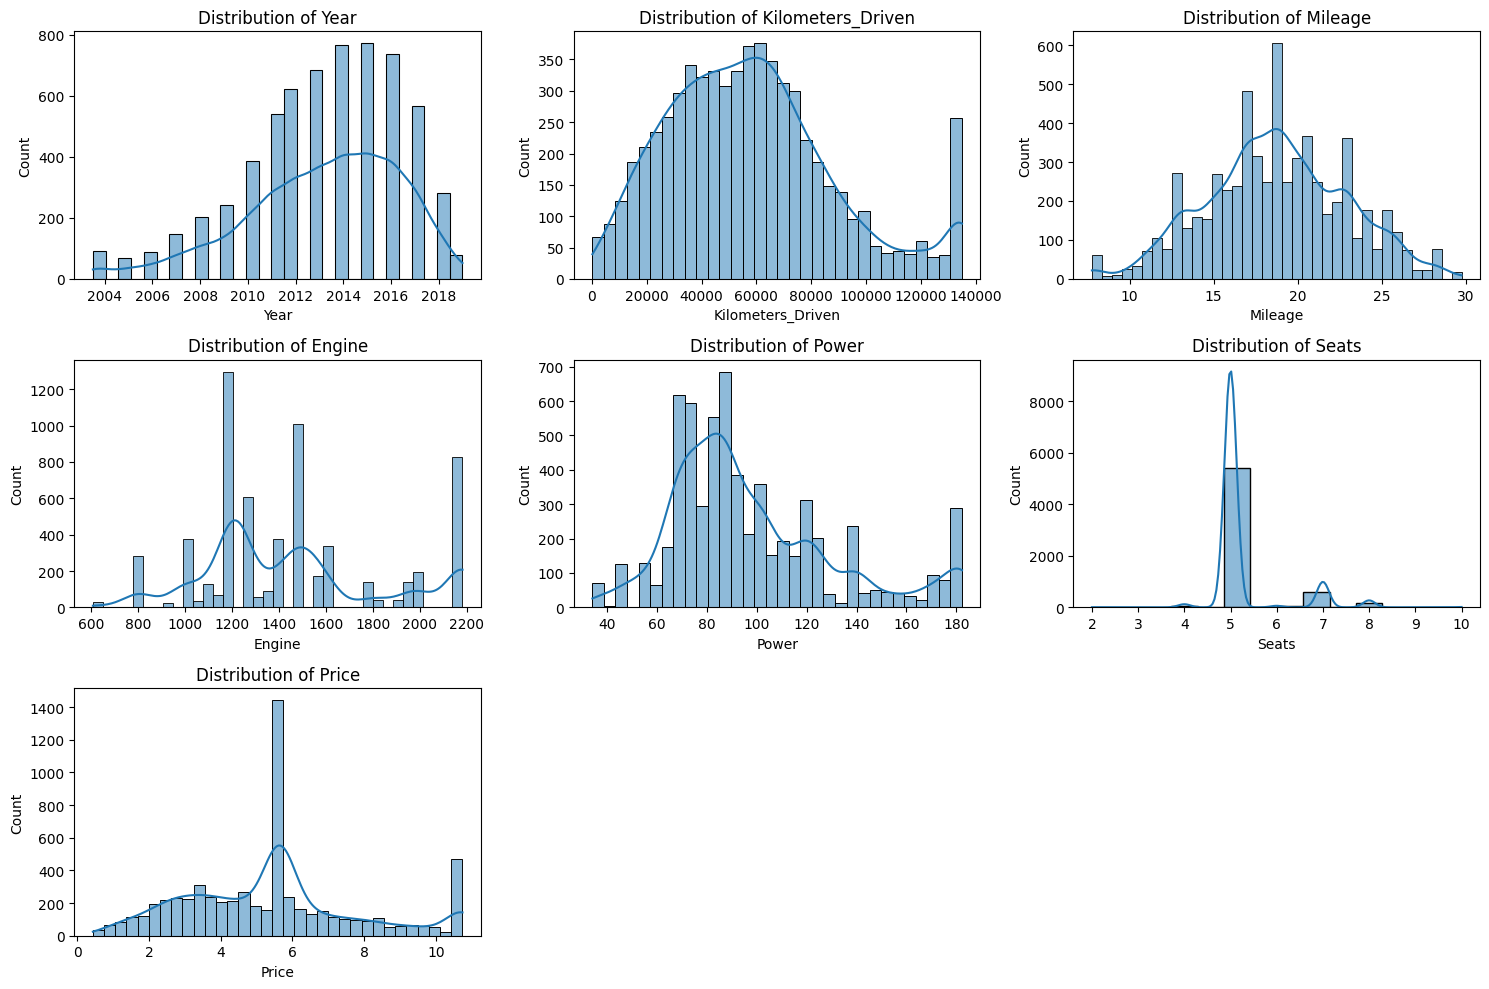

In [ ]:
numerical_cols_for_analysis = ['Year', 'Kilometers_Driven', 'Mileage', 'Engine', 'Power', 'Seats', 'Price']

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols_for_analysis):
    plt.subplot(3, 3, i + 1)
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

Most cars in the dataset are from recent years (2013–2016) and usually have around 50,000–60,000 km driven. Mileage is commonly between 15–20, engines around 1200–1400 cc, and power near 60–100. Most cars have 5 seats, and prices cluster around 4–5 units, showing typical mid-range vehicles.

#### Distribution of Categorical Features (Count Plots)

/tmp/ipykernel_14779/1061587224.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[col], order=df[col].value_counts().index, palette='viridis')
/tmp/ipykernel_14779/1061587224.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[col], order=df[col].value_counts().index, palette='viridis')
/tmp/ipykernel_14779/1061587224.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[col], order=df[col].value_counts().index, palette='viridis')
/tmp/ipykernel_14779/1061587224.py:6: FutureWarning: 

Passing `palette` without assigning 

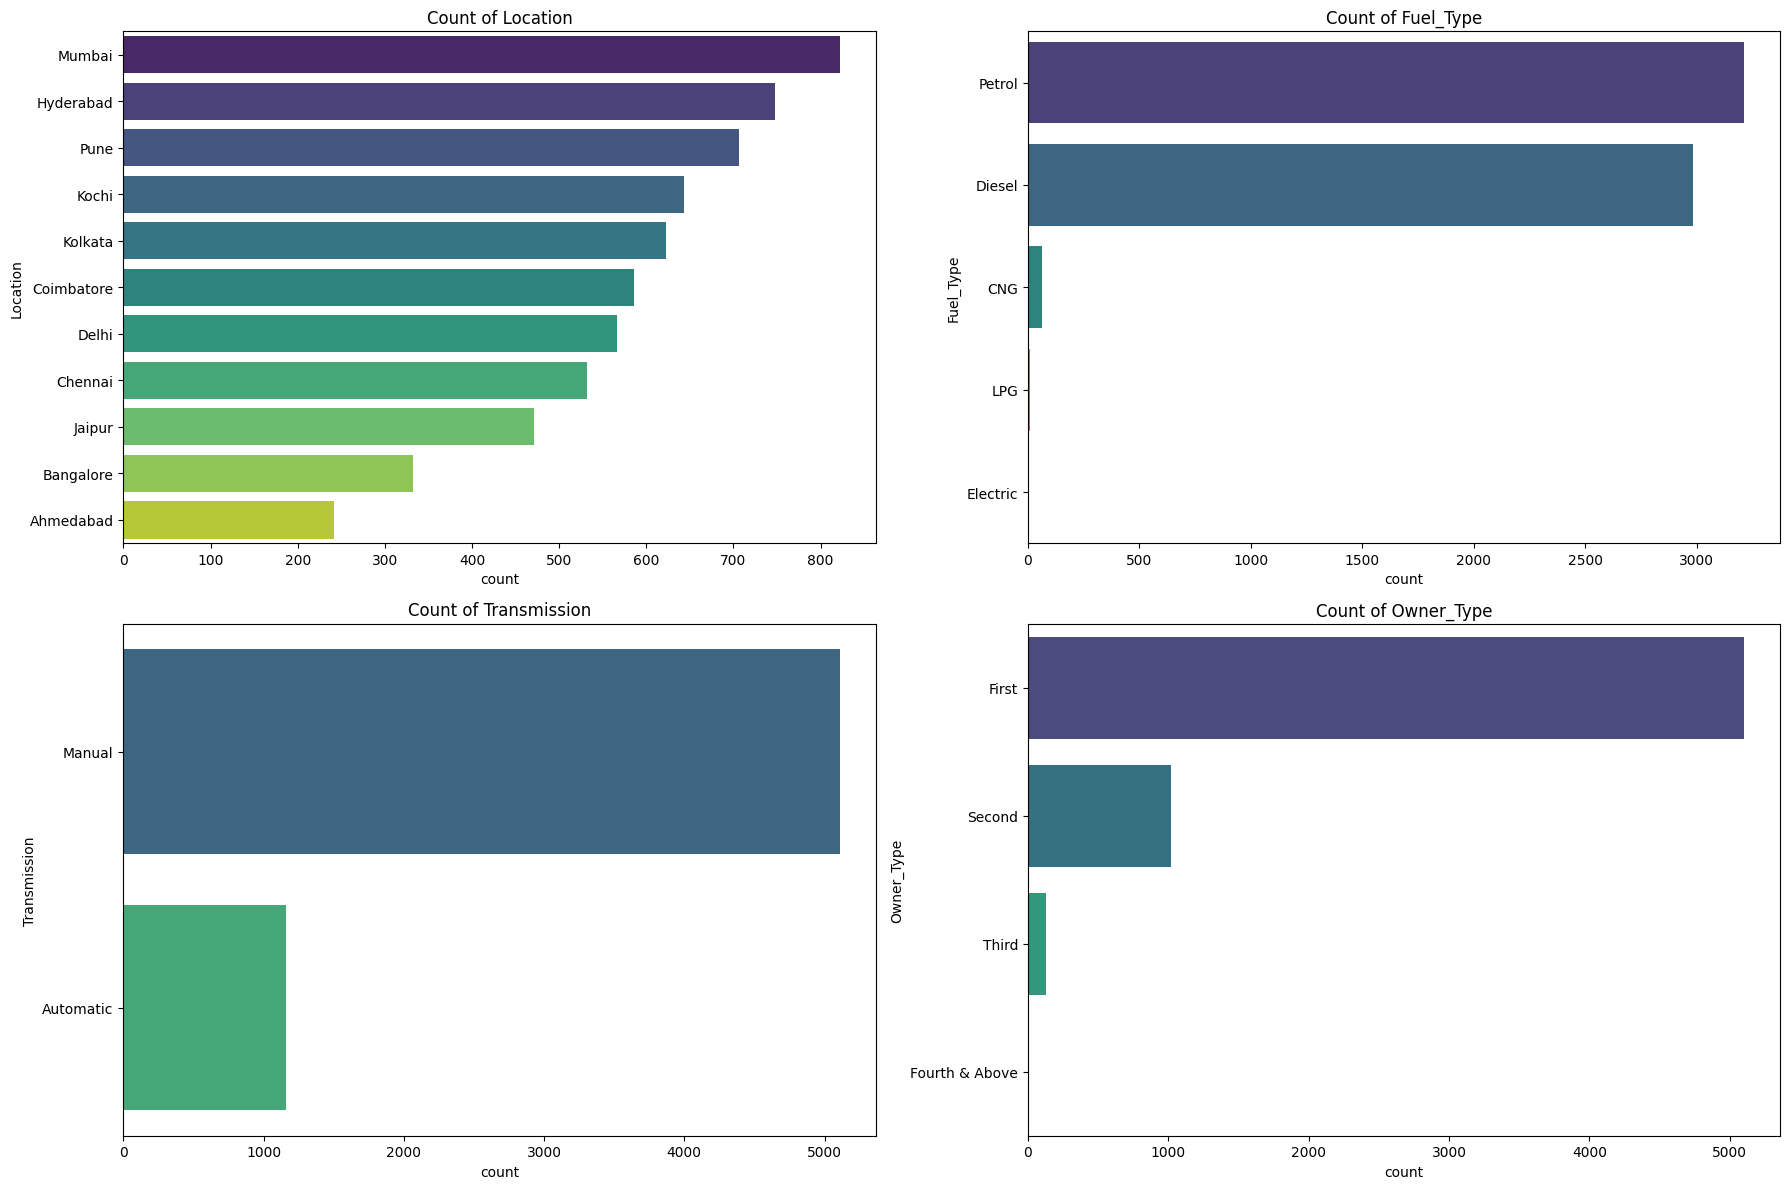

In [ ]:
categorical_cols_for_analysis = ['Location', 'Fuel_Type', 'Transmission', 'Owner_Type']

plt.figure(figsize=(18, 12))
for i, col in enumerate(categorical_cols_for_analysis):
    plt.subplot(2, 2, i + 1)
    sns.countplot(y=df[col], order=df[col].value_counts().index, palette='viridis')
    plt.title(f'Count of {col}')
plt.tight_layout()
plt.show()

Mumbai has the most car listings, followed by Hyderabad and Pune, while Ahmedabad has the least. Petrol and Diesel cars dominate, with very few CNG, LPG, or Electric. Manual transmission is far more common than Automatic. Most cars are first-owner, with second-owner being next, and very few third or fourth-owner cars.

### Bivariate Analysis

#### Numerical Features vs. Price (Scatter Plots)

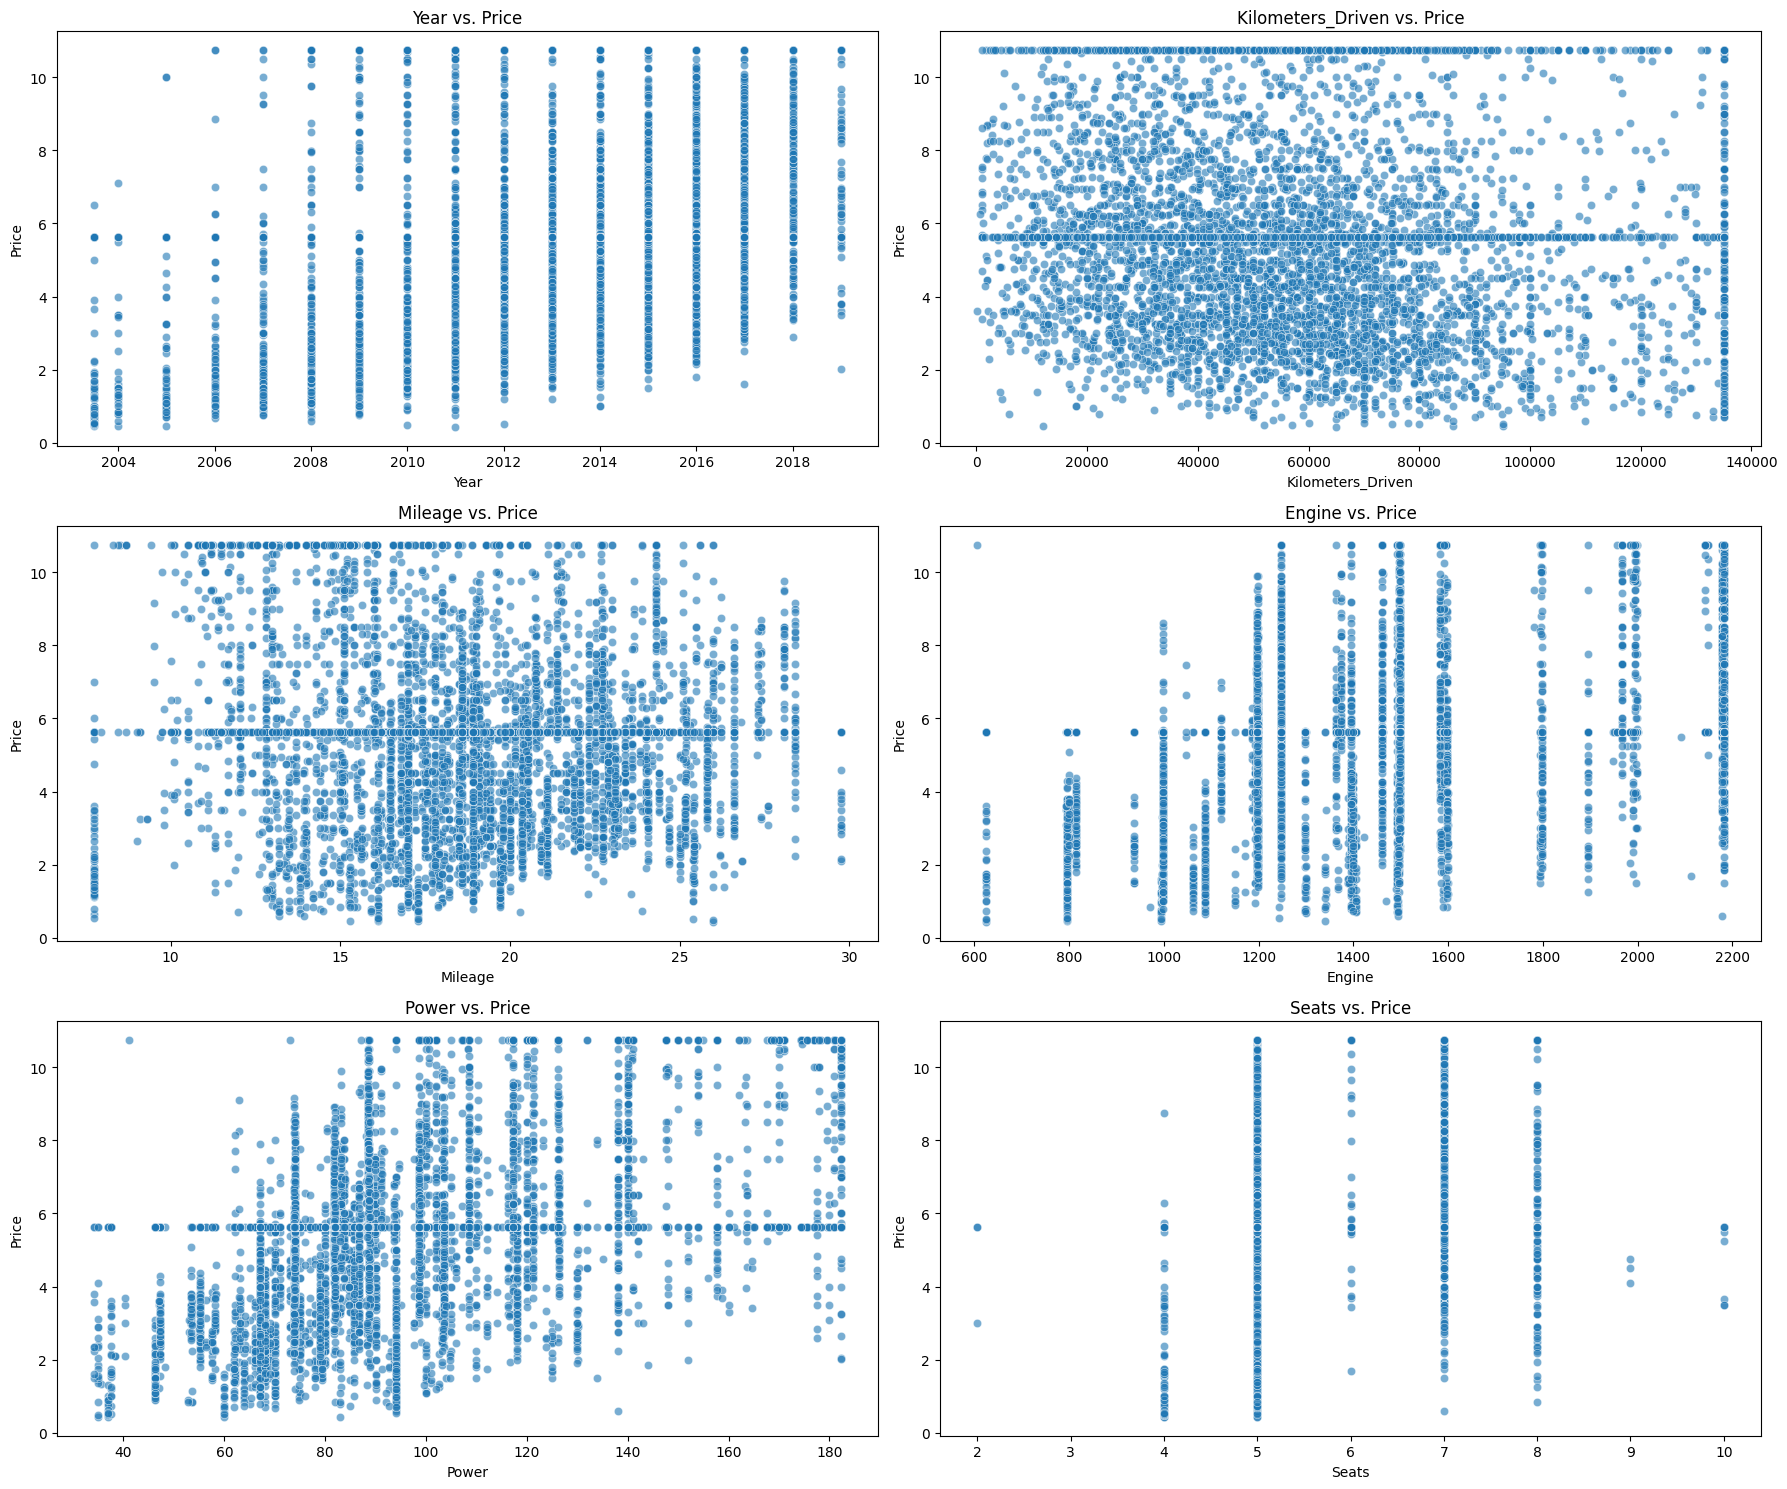

In [ ]:
numerical_features_vs_price = ['Year', 'Kilometers_Driven', 'Mileage', 'Engine', 'Power', 'Seats']

plt.figure(figsize=(18, 15))
for i, col in enumerate(numerical_features_vs_price):
    plt.subplot(3, 2, i + 1)
    sns.scatterplot(x=df[col], y=df['Price'], alpha=0.6)
    plt.title(f'{col} vs. Price')
plt.tight_layout()
plt.show()

Newer cars (2013–2016) usually sell at higher prices, while older ones drop in value. Cars with fewer kilometers driven tend to be priced higher, and more powerful engines or higher horsepower also push prices up. Mileage and seat count don’t show a strong link with price compared to year, kilometers, engine, and power.

#### Categorical Features vs. Price (Box Plots)

/tmp/ipykernel_14779/4266341868.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[col], y=df['Price'], palette='muted')
/tmp/ipykernel_14779/4266341868.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[col], y=df['Price'], palette='muted')
/tmp/ipykernel_14779/4266341868.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[col], y=df['Price'], palette='muted')
/tmp/ipykernel_14779/4266341868.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable

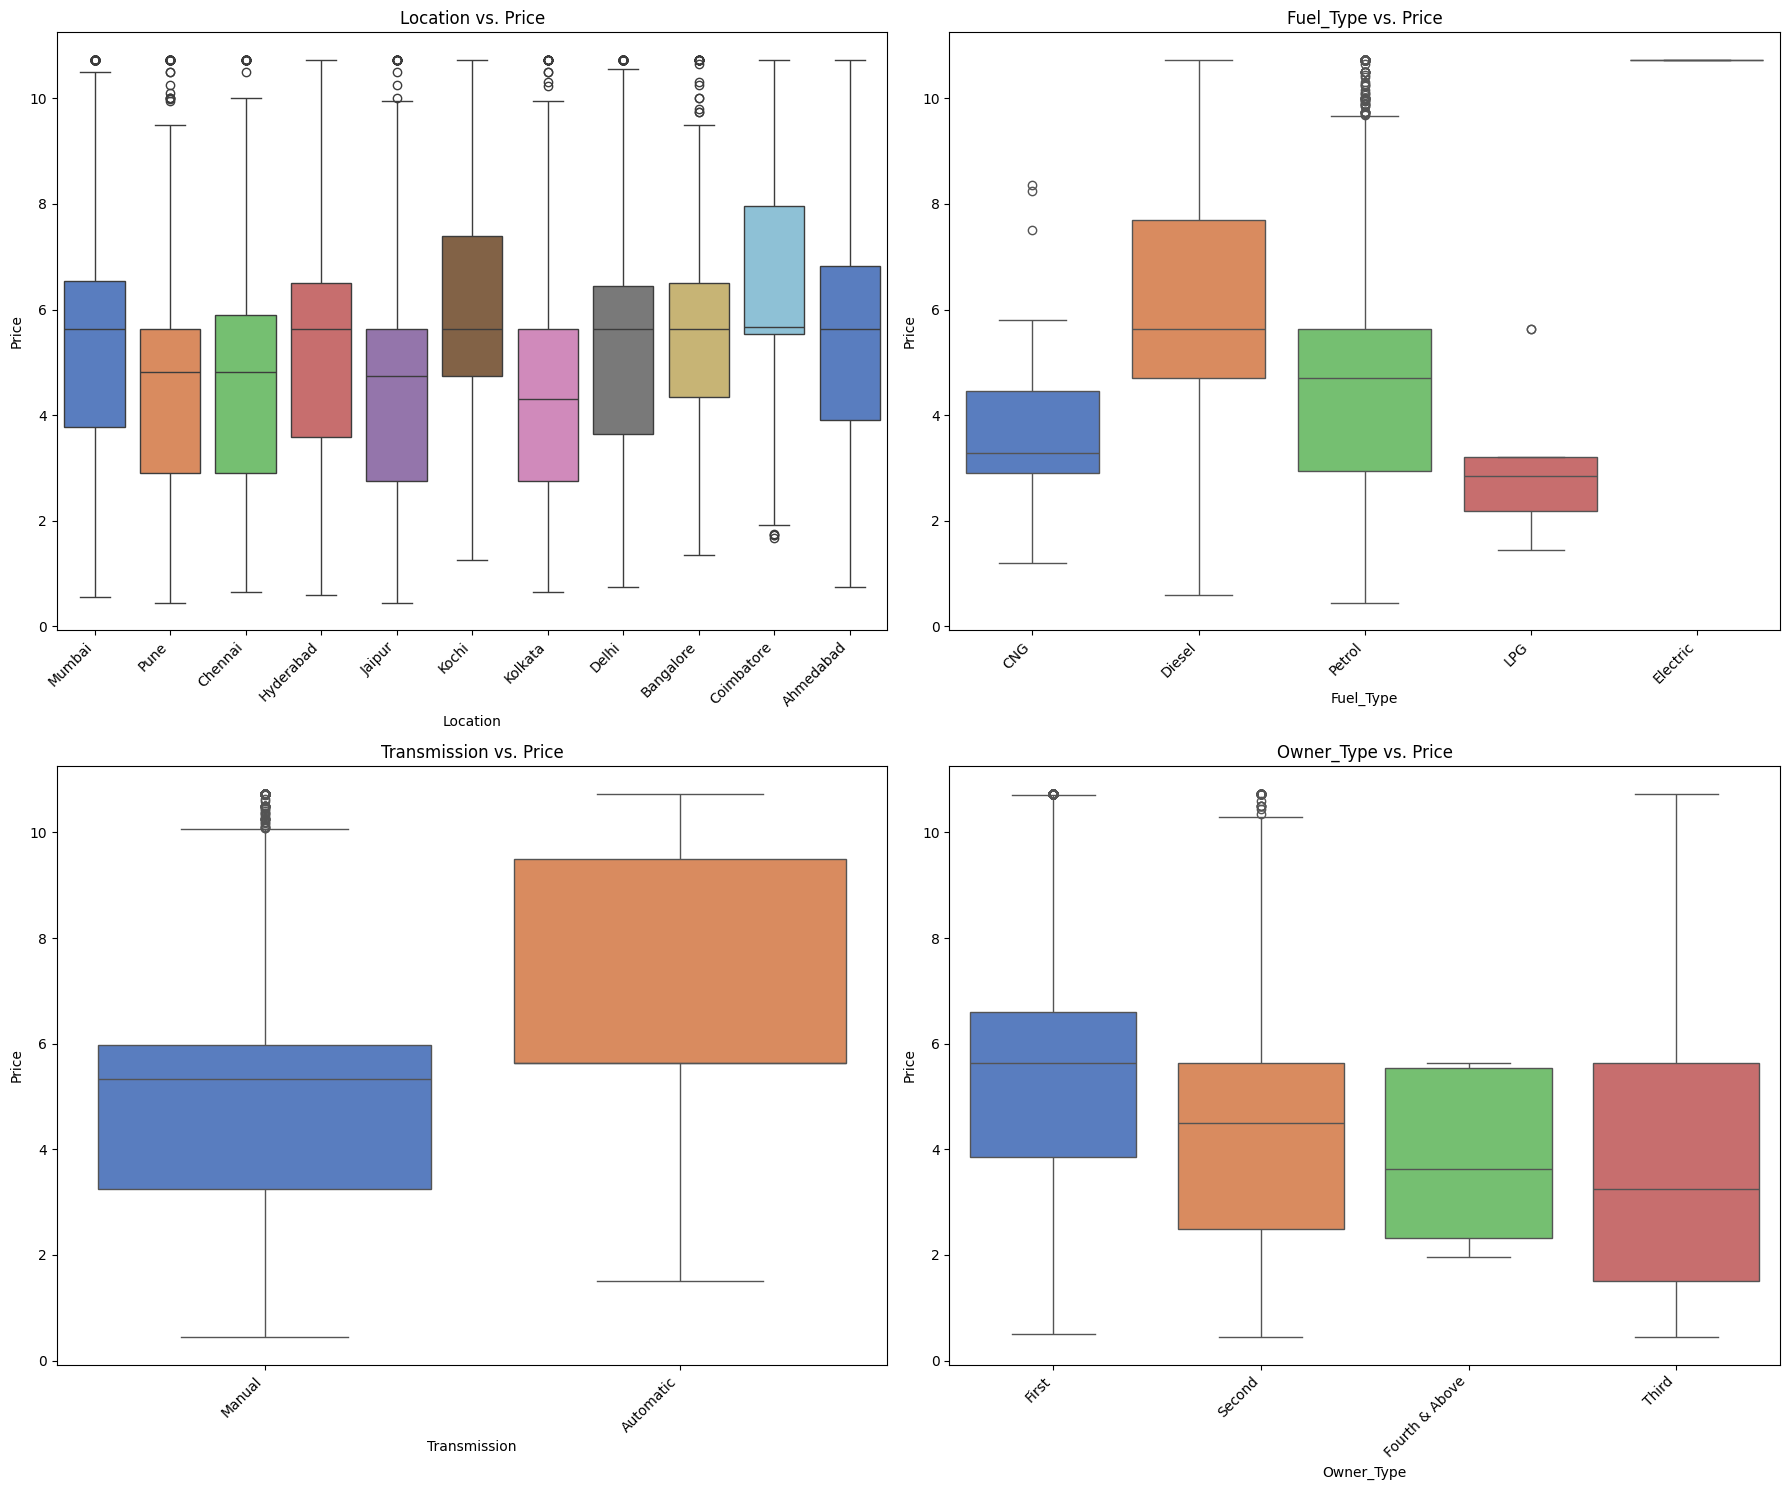

In [ ]:
categorical_features_vs_price = ['Location', 'Fuel_Type', 'Transmission', 'Owner_Type']

plt.figure(figsize=(18, 15))
for i, col in enumerate(categorical_features_vs_price):
    plt.subplot(2, 2, i + 1)
    sns.boxplot(x=df[col], y=df['Price'], palette='muted')
    plt.title(f'{col} vs. Price')
    plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Cars in Mumbai, Pune, and Hyderabad show higher price ranges compared to smaller cities. Diesel cars generally cost more than Petrol, while CNG, LPG, and Electric are less common but vary widely. Automatic cars are priced higher than Manual ones. First-owner cars hold the best value, while cars with multiple previous owners usually sell cheaper.

### Multivariate Analysis

#### Correlation Matrix of Numerical Features

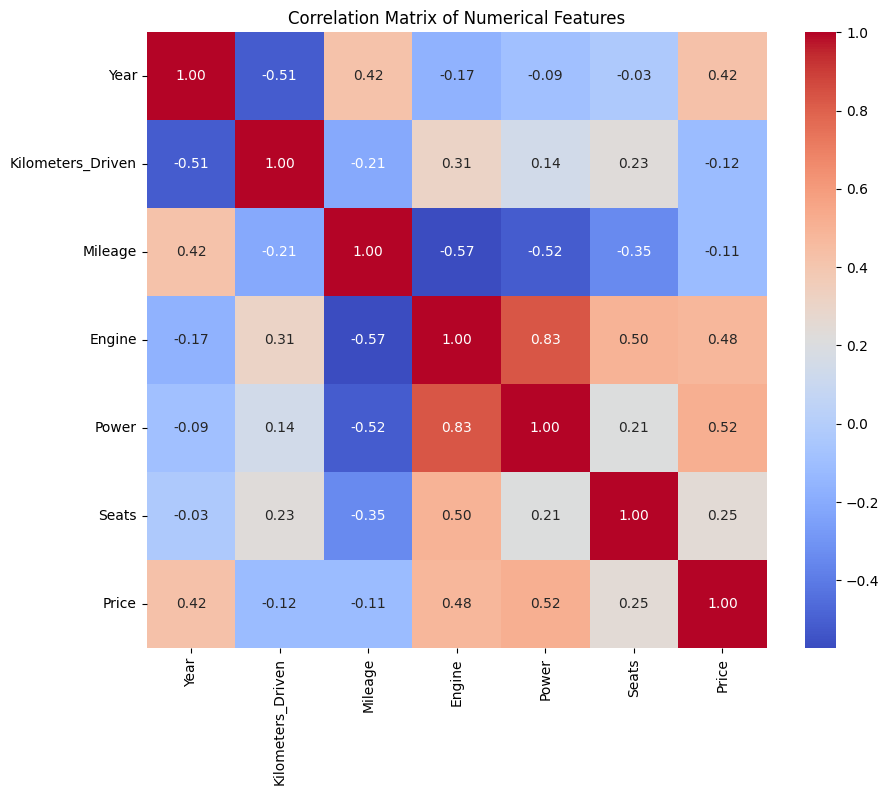

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(df[numerical_cols_for_analysis].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

#### Pair Plot for a subset of Numerical Features

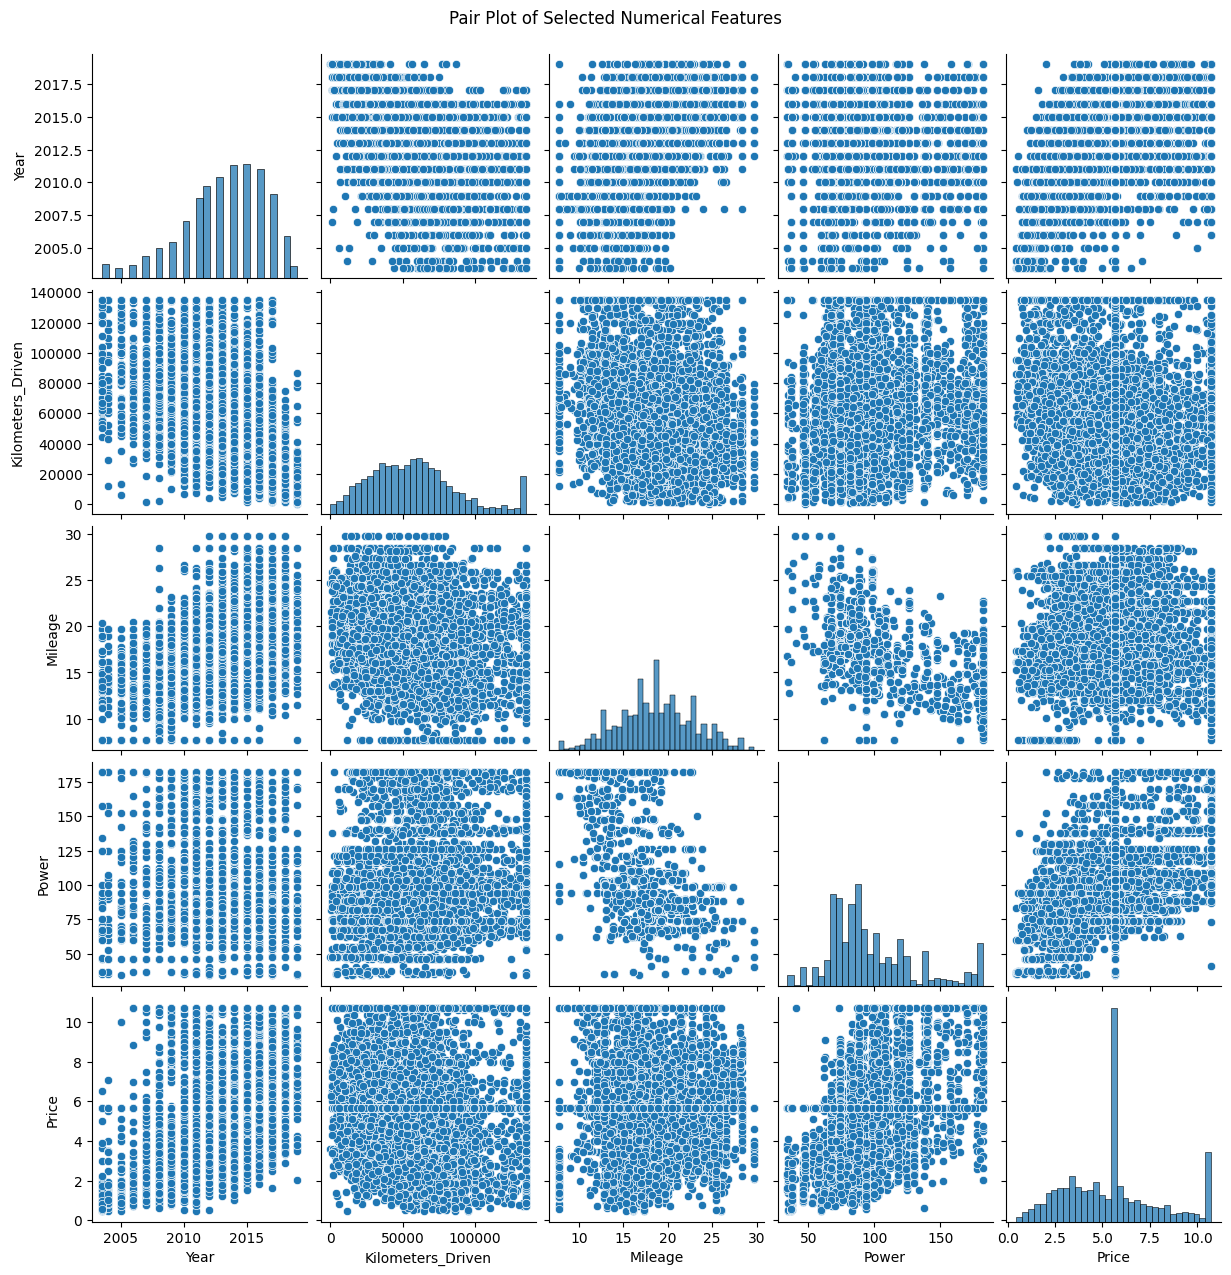

In [ ]:
# Using a subset of numerical columns for better readability in pair plot
subset_numerical_cols = ['Year', 'Kilometers_Driven', 'Mileage', 'Power', 'Price']
sns.pairplot(df[subset_numerical_cols])
plt.suptitle('Pair Plot of Selected Numerical Features', y=1.02)
plt.show()

This pair plot shows how car features connect with price. Newer cars and higher power values usually link with higher prices, while more kilometers driven lowers price. Mileage has a weaker effect, but overall you can see that year, power, and kilometers are the strongest factors shaping car value.

### Train-Test Split, Feature Scaling and Encoding

In [ ]:
# Define features (X) and target (y)
X = df.drop('Price', axis=1)
y = df['Price']

# Drop 'Name' column as it's high cardinality and not suitable for one-hot encoding in this context
X = X.drop('Name', axis=1)

# Identify numerical and categorical features
numerical_features = X.select_dtypes(include=np.number).columns
categorical_features = X.select_dtypes(include='object').columns

print(f"Features for X: {X.columns.tolist()}")
print(f"Numerical features: {numerical_features.tolist()}")
print(f"Categorical features: {categorical_features.tolist()}")

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\nShape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Features for X: ['Location', 'Year', 'Kilometers_Driven', 'Fuel_Type', 'Transmission', 'Owner_Type', 'Mileage', 'Engine', 'Power', 'Seats']
Numerical features: ['Year', 'Kilometers_Driven', 'Mileage', 'Engine', 'Power', 'Seats']
Categorical features: ['Location', 'Fuel_Type', 'Transmission', 'Owner_Type']

Shape of X_train: (5016, 10)
Shape of X_test: (1255, 10)
Shape of y_train: (5016,)
Shape of y_test: (1255,)


In [ ]:
# Define features (X) and target (y)
X = df.drop('Price', axis=1)
y = df['Price']

# Feature Engineering
# 1. Create 'Car_Age' from 'Year'
current_year = 2024 # Assuming current year for calculation
X['Car_Age'] = current_year - X['Year']

# 2. Extract 'Brand' from 'Name'
X['Brand'] = X['Name'].apply(lambda x: x.split(' ')[0])

# Drop 'Name' column as it's high cardinality and not suitable for one-hot encoding in this context
X = X.drop('Name', axis=1)

# Identify numerical and categorical features
numerical_features = X.select_dtypes(include=np.number).columns
categorical_features = X.select_dtypes(include='object').columns

print(f"Features for X: {X.columns.tolist()}")
print(f"Numerical features: {numerical_features.tolist()}")
print(f"Categorical features: {categorical_features.tolist()}")

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\nShape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

# Create preprocessing pipelines for numerical and categorical features
numerical_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Create a column transformer to apply different transformations to different columns
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# Fit and transform the training data
X_train_processed = preprocessor.fit_transform(X_train)

# Transform the test data
X_test_processed = preprocessor.transform(X_test)

print(f"\nShape of processed X_train: {X_train_processed.shape}")
print(f"Shape of processed X_test: {X_test_processed.shape}")

Features for X: ['Location', 'Year', 'Kilometers_Driven', 'Fuel_Type', 'Transmission', 'Owner_Type', 'Mileage', 'Engine', 'Power', 'Seats', 'Car_Age', 'Brand']
Numerical features: ['Year', 'Kilometers_Driven', 'Mileage', 'Engine', 'Power', 'Seats', 'Car_Age']
Categorical features: ['Location', 'Fuel_Type', 'Transmission', 'Owner_Type', 'Brand']

Shape of X_train: (5016, 12)
Shape of X_test: (1255, 12)
Shape of y_train: (5016,)
Shape of y_test: (1255,)

Shape of processed X_train: (5016, 61)
Shape of processed X_test: (1255, 61)


### Model Training and Evaluation: Linear Regression

In [ ]:
from sklearn.linear_model import LinearRegression

# Initialize the Linear Regression model
linear_model = LinearRegression()

# Train the model
linear_model.fit(X_train_processed, y_train)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


In [ ]:
# Make predictions on the processed test data
y_pred_linear = linear_model.predict(X_test_processed)

# Evaluate the model
mse_linear = mean_squared_error(y_test, y_pred_linear)
r2_linear = r2_score(y_test, y_pred_linear)

print(f"\nLinear Regression Model Performance:")
print(f"Mean Squared Error (MSE): {mse_linear:.2f}")
print(f"R-squared (R2): {r2_linear:.2f}")


Linear Regression Model Performance:
Mean Squared Error (MSE): 2.61
R-squared (R2): 0.55


### Model Training and Evaluation: Support Vector Regressor (SVR)

In [ ]:
from sklearn.svm import SVR

# Initialize the SVR model
svr_model = SVR()

# Train the model
svr_model.fit(X_train_processed, y_train)

print("SVR model trained successfully.")

# Make predictions on the processed test data
y_pred_svr = svr_model.predict(X_test_processed)

# Evaluate the model
mse_svr = mean_squared_error(y_test, y_pred_svr)
r2_svr = r2_score(y_test, y_pred_svr)

print(f"\nSVR Model Performance:")
print(f"Mean Squared Error (MSE): {mse_svr:.2f}")
print(f"R-squared (R2): {r2_svr:.2f}")

SVR model trained successfully.

SVR Model Performance:
Mean Squared Error (MSE): 1.80
R-squared (R2): 0.69


### Model Training and Evaluation: K-Nearest Neighbors (KNN) Regressor

In [ ]:
from sklearn.neighbors import KNeighborsRegressor

# Initialize the KNN Regressor model
knn_model = KNeighborsRegressor()

# Train the model
knn_model.fit(X_train_processed, y_train)

print("KNN Regressor model trained successfully.")

# Make predictions on the processed test data
y_pred_knn = knn_model.predict(X_test_processed)

# Evaluate the model
mse_knn = mean_squared_error(y_test, y_pred_knn)
r2_knn = r2_score(y_test, y_pred_knn)

print(f"\nKNN Regressor Model Performance:")
print(f"Mean Squared Error (MSE): {mse_knn:.2f}")
print(f"R-squared (R2): {r2_knn:.2f}")

KNN Regressor model trained successfully.

KNN Regressor Model Performance:
Mean Squared Error (MSE): 2.19
R-squared (R2): 0.63


### Model Training and Evaluation: Bagging Regressor

In [ ]:
from sklearn.ensemble import BaggingRegressor

# Initialize the Bagging Regressor model
bagging_model = BaggingRegressor(random_state=42)

# Train the model
bagging_model.fit(X_train_processed, y_train)

print("Bagging Regressor model trained successfully.")

# Make predictions on the processed test data
y_pred_bagging = bagging_model.predict(X_test_processed)

# Evaluate the model
mse_bagging = mean_squared_error(y_test, y_pred_bagging)
r2_bagging = r2_score(y_test, y_pred_bagging)

print(f"\nBagging Regressor Model Performance:")
print(f"Mean Squared Error (MSE): {mse_bagging:.2f}")
print(f"R-squared (R2): {r2_bagging:.2f}")

Bagging Regressor model trained successfully.

Bagging Regressor Model Performance:
Mean Squared Error (MSE): 1.95
R-squared (R2): 0.67


### Model Training and Evaluation: AdaBoost Regressor

In [ ]:
from sklearn.ensemble import AdaBoostRegressor

# Initialize the AdaBoost Regressor model
adaboost_model = AdaBoostRegressor(random_state=42)

# Train the model
adaboost_model.fit(X_train_processed, y_train)

print("AdaBoost Regressor model trained successfully.")

# Make predictions on the processed test data
y_pred_adaboost = adaboost_model.predict(X_test_processed)

# Evaluate the model
mse_adaboost = mean_squared_error(y_test, y_pred_adaboost)
r2_adaboost = r2_score(y_test, y_pred_adaboost)

print(f"\nAdaBoost Regressor Model Performance:")
print(f"Mean Squared Error (MSE): {mse_adaboost:.2f}")
print(f"R-squared (R2): {r2_adaboost:.2f}")

AdaBoost Regressor model trained successfully.

AdaBoost Regressor Model Performance:
Mean Squared Error (MSE): 2.91
R-squared (R2): 0.50


### Model Training and Evaluation: Random Forest Regressor

In [ ]:
# Initialize the Random Forest Regressor model
rf_model = RandomForestRegressor(random_state=42)

# Train the model
rf_model.fit(X_train_processed, y_train)

print("Random Forest Regressor model trained successfully.")

# Make predictions on the processed test data
y_pred_rf = rf_model.predict(X_test_processed)

# Evaluate the model
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"\nRandom Forest Regressor Model Performance:")
print(f"Mean Squared Error (MSE): {mse_rf:.2f}")
print(f"R-squared (R2): {r2_rf:.2f}")

Random Forest Regressor model trained successfully.

Random Forest Regressor Model Performance:
Mean Squared Error (MSE): 1.86
R-squared (R2): 0.68


### Model Training and Evaluation: Stacking Regressor

In [ ]:
from sklearn.ensemble import StackingRegressor

# Define base estimators for Stacking
estimators = [
    ('lr', LinearRegression()),
    ('rf', RandomForestRegressor(random_state=42)),
    ('svr', SVR())
]

# Initialize the Stacking Regressor model with a final estimator (e.g., Ridge Regression)
stacking_model = StackingRegressor(estimators=estimators, final_estimator=LinearRegression(), cv=5)

# Train the model
stacking_model.fit(X_train_processed, y_train)

print("Stacking Regressor model trained successfully.")

# Make predictions on the processed test data
y_pred_stacking = stacking_model.predict(X_test_processed)

# Evaluate the model
mse_stacking = mean_squared_error(y_test, y_pred_stacking)
r2_stacking = r2_score(y_test, y_pred_stacking)

print(f"\nStacking Regressor Model Performance:")
print(f"Mean Squared Error (MSE): {mse_stacking:.2f}")
print(f"R-squared (R2): {r2_stacking:.2f}")

Stacking Regressor model trained successfully.

Stacking Regressor Model Performance:
Mean Squared Error (MSE): 1.69
R-squared (R2): 0.71


### Model Performance Comparison


--- Model Performance (Sorted by MSE) ---


,Model,MSE,RMSE,MAE,R2 Score
6,Stacking Regressor,1.694786,1.301839,0.974389,0.710529
1,SVR,1.804925,1.343475,0.954962,0.691717
5,Random Forest Regressor,1.861338,1.364309,1.015591,0.682082
3,Bagging Regressor,1.954108,1.397894,1.028226,0.666237
2,KNN Regressor,2.187528,1.479030,1.127186,0.626368
0,Linear Regression,2.612327,1.616270,1.231158,0.553812
4,AdaBoost Regressor,2.906397,1.704816,1.446527,0.503585



--- Model Performance (Sorted by RMSE) ---


,Model,MSE,RMSE,MAE,R2 Score
6,Stacking Regressor,1.694786,1.301839,0.974389,0.710529
1,SVR,1.804925,1.343475,0.954962,0.691717
5,Random Forest Regressor,1.861338,1.364309,1.015591,0.682082
3,Bagging Regressor,1.954108,1.397894,1.028226,0.666237
2,KNN Regressor,2.187528,1.479030,1.127186,0.626368
0,Linear Regression,2.612327,1.616270,1.231158,0.553812
4,AdaBoost Regressor,2.906397,1.704816,1.446527,0.503585



--- Model Performance (Sorted by MAE) ---


,Model,MSE,RMSE,MAE,R2 Score
1,SVR,1.804925,1.343475,0.954962,0.691717
6,Stacking Regressor,1.694786,1.301839,0.974389,0.710529
5,Random Forest Regressor,1.861338,1.364309,1.015591,0.682082
3,Bagging Regressor,1.954108,1.397894,1.028226,0.666237
2,KNN Regressor,2.187528,1.479030,1.127186,0.626368
0,Linear Regression,2.612327,1.616270,1.231158,0.553812
4,AdaBoost Regressor,2.906397,1.704816,1.446527,0.503585



--- Model Performance (Sorted by R2 Score) ---


,Model,MSE,RMSE,MAE,R2 Score
6,Stacking Regressor,1.694786,1.301839,0.974389,0.710529
1,SVR,1.804925,1.343475,0.954962,0.691717
5,Random Forest Regressor,1.861338,1.364309,1.015591,0.682082
3,Bagging Regressor,1.954108,1.397894,1.028226,0.666237
2,KNN Regressor,2.187528,1.479030,1.127186,0.626368
0,Linear Regression,2.612327,1.616270,1.231158,0.553812
4,AdaBoost Regressor,2.906397,1.704816,1.446527,0.503585


/tmp/ipykernel_14779/2793587372.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='MSE', data=performance_df_sorted_mse, palette='viridis')


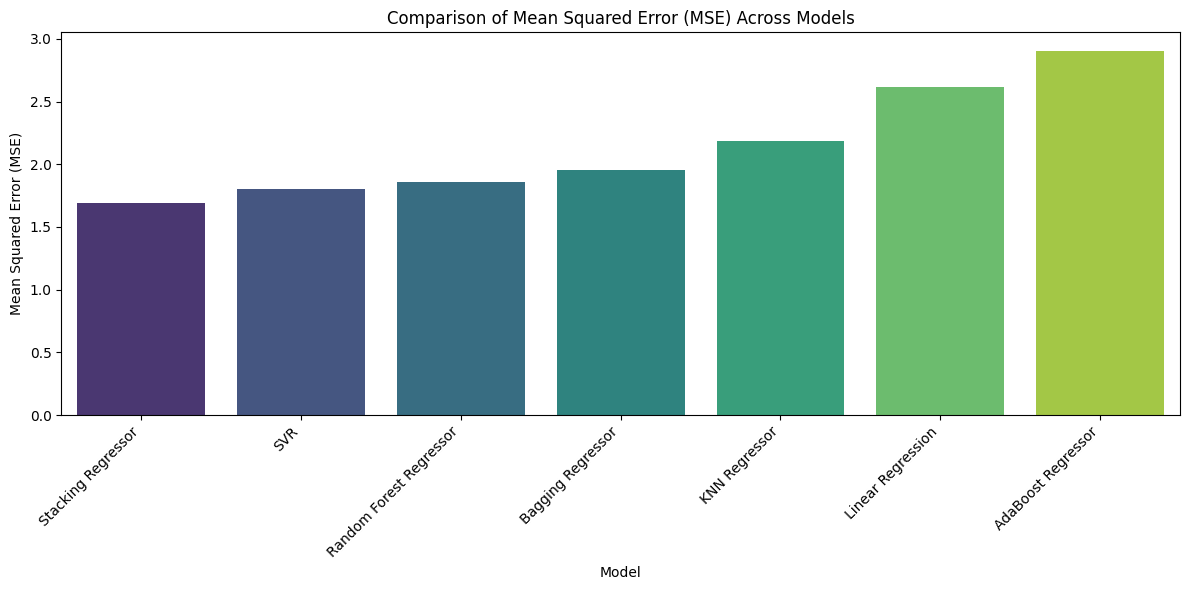

/tmp/ipykernel_14779/2793587372.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='RMSE', data=performance_df_sorted_rmse, palette='cividis')


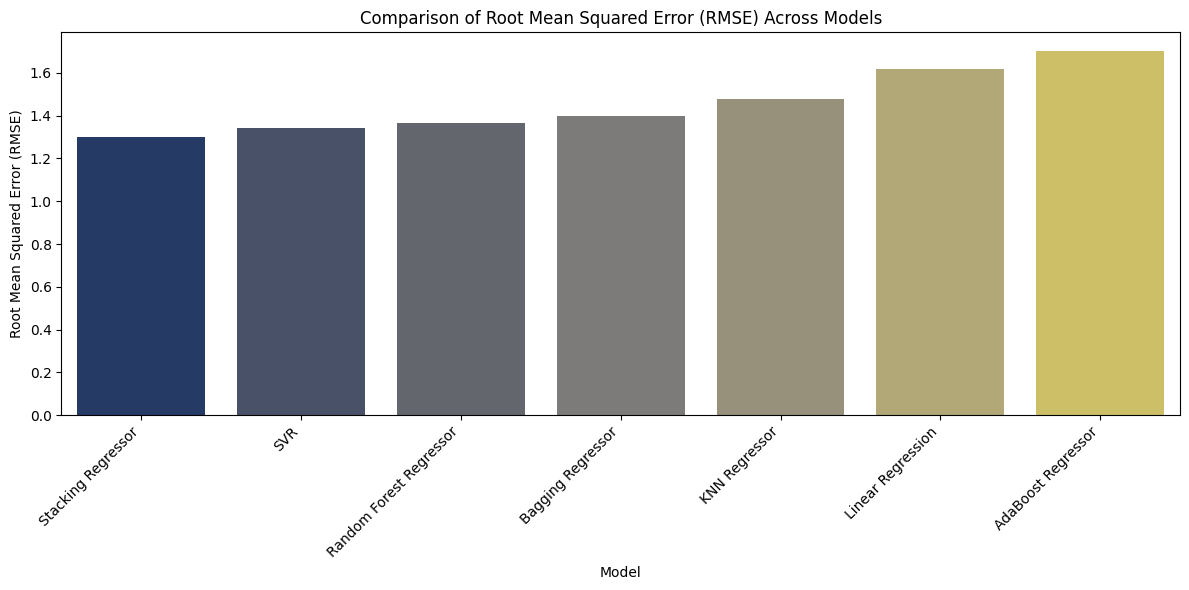

/tmp/ipykernel_14779/2793587372.py:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='MAE', data=performance_df_sorted_mae, palette='magma')


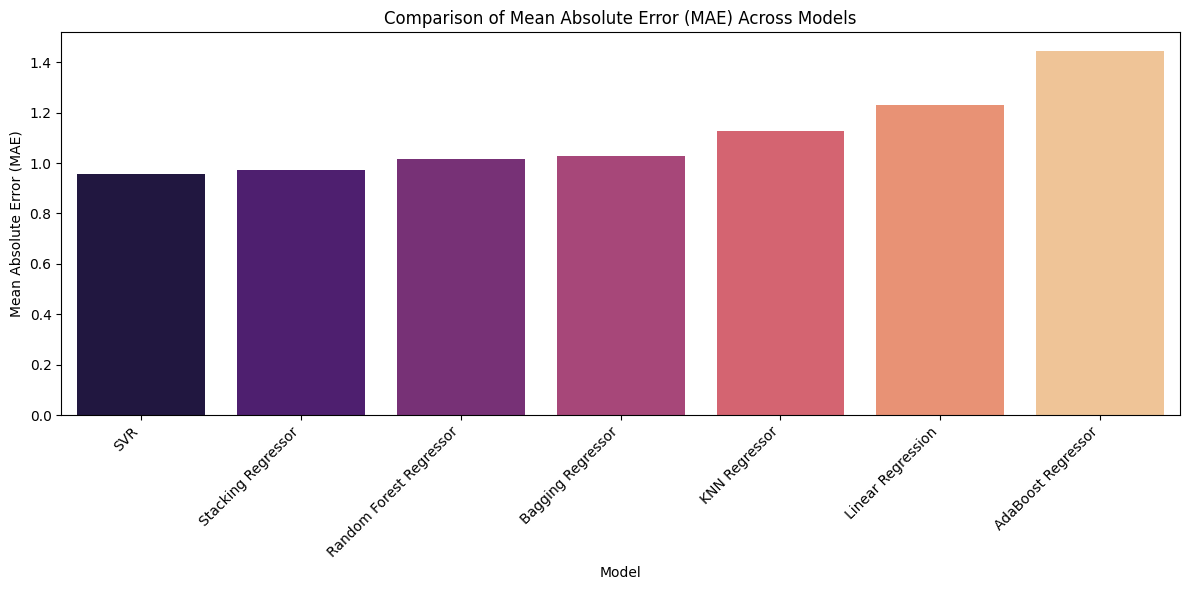

/tmp/ipykernel_14779/2793587372.py:77: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='R2 Score', data=performance_df_sorted_r2, palette='plasma')


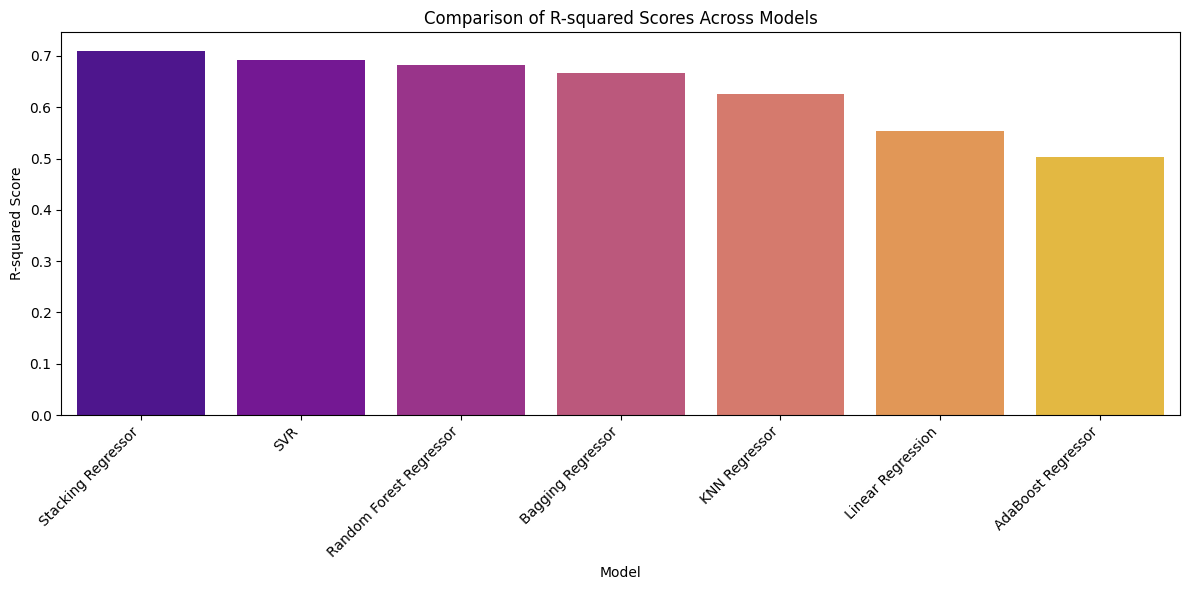

In [ ]:
from sklearn.metrics import mean_absolute_error

model_names = ['Linear Regression', 'SVR', 'KNN Regressor', 'Bagging Regressor', 'AdaBoost Regressor', 'Random Forest Regressor', 'Stacking Regressor']
mse_scores = [mse_linear, mse_svr, mse_knn, mse_bagging, mse_adaboost, mse_rf, mse_stacking]
r2_scores = [r2_linear, r2_svr, r2_knn, r2_bagging, r2_adaboost, r2_rf, r2_stacking]

# Calculate RMSE scores (RMSE = sqrt(MSE))
rmse_scores = [np.sqrt(mse) for mse in mse_scores]

# Calculate MAE scores
mae_linear = mean_absolute_error(y_test, y_pred_linear)
mae_svr = mean_absolute_error(y_test, y_pred_svr)
mae_knn = mean_absolute_error(y_test, y_pred_knn)
mae_bagging = mean_absolute_error(y_test, y_pred_bagging)
mae_adaboost = mean_absolute_error(y_test, y_pred_adaboost)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mae_stacking = mean_absolute_error(y_test, y_pred_stacking)
mae_scores = [mae_linear, mae_svr, mae_knn, mae_bagging, mae_adaboost, mae_rf, mae_stacking]

performance_df = pd.DataFrame({
    'Model': model_names,
    'MSE': mse_scores,
    'RMSE': rmse_scores,
    'MAE': mae_scores,
    'R2 Score': r2_scores
})

performance_df_sorted_mse = performance_df.sort_values(by='MSE', ascending=True)
performance_df_sorted_rmse = performance_df.sort_values(by='RMSE', ascending=True)
performance_df_sorted_mae = performance_df.sort_values(by='MAE', ascending=True)
performance_df_sorted_r2 = performance_df.sort_values(by='R2 Score', ascending=False)

print("\n--- Model Performance (Sorted by MSE) ---")
display(performance_df_sorted_mse)

print("\n--- Model Performance (Sorted by RMSE) ---")
display(performance_df_sorted_rmse)

print("\n--- Model Performance (Sorted by MAE) ---")
display(performance_df_sorted_mae)

print("\n--- Model Performance (Sorted by R2 Score) ---")
display(performance_df_sorted_r2)

# Visualize MSE scores
plt.figure(figsize=(12, 6))
sns.barplot(x='Model', y='MSE', data=performance_df_sorted_mse, palette='viridis')
plt.title('Comparison of Mean Squared Error (MSE) Across Models')
plt.ylabel('Mean Squared Error (MSE)')
plt.xlabel('Model')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Visualize RMSE scores
plt.figure(figsize=(12, 6))
sns.barplot(x='Model', y='RMSE', data=performance_df_sorted_rmse, palette='cividis')
plt.title('Comparison of Root Mean Squared Error (RMSE) Across Models')
plt.ylabel('Root Mean Squared Error (RMSE)')
plt.xlabel('Model')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Visualize MAE scores
plt.figure(figsize=(12, 6))
sns.barplot(x='Model', y='MAE', data=performance_df_sorted_mae, palette='magma')
plt.title('Comparison of Mean Absolute Error (MAE) Across Models')
plt.ylabel('Mean Absolute Error (MAE)')
plt.xlabel('Model')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Visualize R-squared scores
plt.figure(figsize=(12, 6))
sns.barplot(x='Model', y='R2 Score', data=performance_df_sorted_r2, palette='plasma')
plt.title('Comparison of R-squared Scores Across Models')
plt.ylabel('R-squared Score')
plt.xlabel('Model')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Across all your evaluation charts, one clear story emerges: ensemble models consistently outperform simpler ones.

📉 Error Metrics (MSE, RMSE, MAE): Stacking Regressor, SVR, Random Forest, and Bagging show the lowest errors, while AdaBoost struggles with the highest.

📈 R² Scores: Stacking Regressor explains the most variance (~0.71), proving it’s the most reliable predictor of car prices.

⚖️ Overall Insight: Stacking Regressor is your best choice, followed by Random Forest and Bagging. AdaBoost is weakest, and Linear Regression/KNN sit in the middle.

This means your project demonstrates that combining models (Stacking) gives the most accurate and stable predictions.

# **final conclusion**

Stacking Regressor gave the best performance with lowest errors and highest R² (~0.71).

Random Forest and Bagging also performed strongly, proving ensemble methods are reliable.

SVR showed good accuracy on MAE but was less consistent overall.

AdaBoost Regressor was the weakest, with highest errors and lowest R².

Overall, ensemble models (especially Stacking) are the most accurate and stable choice for car price prediction.